In [1]:
# Import required libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

In [2]:
# Kaggle automatically stores added datasets inside /kaggle/input/

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/princelv84
/kaggle/input/datasets/princelv84/dogsvscats
/kaggle/input/datasets/princelv84/dogsvscats/test
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs
/kaggle/input/datasets/princelv84/dogsvscats/test/cats
/kaggle/input/datasets/princelv84/dogsvscats/train
/kaggle/input/datasets/princelv84/dogsvscats/train/dogs
/kaggle/input/datasets/princelv84/dogsvscats/train/cats


In [3]:
# Find train and test folders automatically

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):

    if os.path.basename(root).lower() == "train":
        train_dir = root

    elif os.path.basename(root).lower() == "test":
        test_dir = root


print("Train directory:", train_dir)
print("Test directory :", test_dir)

Train directory: /kaggle/input/datasets/princelv84/dogsvscats/train
Test directory : /kaggle/input/datasets/princelv84/dogsvscats/test


In [4]:
# Check the class folders inside the training directory

print("Classes in training data:")

for folder in os.listdir(train_dir):
    print(folder)

Classes in training data:
dogs
cats


In [5]:
# Load VGG16 pretrained on ImageNet
#
# include_top=False removes the original ImageNet classifier.
# We will create our own classifier for Cats vs Dogs.

conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150, 150, 3)
)

conv_base.summary()

I0000 00:00:1790847604.101589      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790847604.104747      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Freeze the VGG16 convolutional layers.
#
# We are using VGG16 as a feature extractor.
# Therefore, its pretrained weights will not be changed.

conv_base.trainable = False

In [7]:
# Create the classification model

model = Sequential()

# VGG16 extracts features from images
model.add(conv_base)

# Convert feature maps into a single vector
model.add(Flatten())

# Fully connected layer
model.add(Dense(256, activation="relu"))

# Binary classification
# Output will be between 0 and 1
model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
# Data augmentation is applied only to the training images.
#
# It creates slightly modified versions of images during training.
# This can help the model generalize better.

batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    # Randomly rotate images
    rotation_range=20,

    # Shift image horizontally
    width_shift_range=0.2,

    # Shift image vertically
    height_shift_range=0.2,

    # Zoom in/out
    zoom_range=0.2,

    # Flip images horizontally
    horizontal_flip=True
)

# For validation/test data we DO NOT apply augmentation.
# We only apply the same VGG16 preprocessing.
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [9]:
# Create the training data generator

train_generator = train_datagen.flow_from_directory(
    train_dir,

    # Resize every image to 150 x 150
    target_size=(150, 150),

    # Number of images processed at one time
    batch_size=batch_size,

    # Binary classification: cat or dog
    class_mode="binary",

    # Shuffle training images
    shuffle=True
)

print("Class mapping:", train_generator.class_indices)

Found 20000 images belonging to 2 classes.
Class mapping: {'cats': 0, 'dogs': 1}


In [10]:
# Create validation/test data generator

validation_generator = test_datagen.flow_from_directory(
    test_dir,

    target_size=(150, 150),

    batch_size=batch_size,

    class_mode="binary",

    # Do not shuffle validation data
    shuffle=False
)

print("Validation class mapping:",
      validation_generator.class_indices)

Found 5000 images belonging to 2 classes.
Validation class mapping: {'cats': 0, 'dogs': 1}


Found 20000 images belonging to 2 classes.


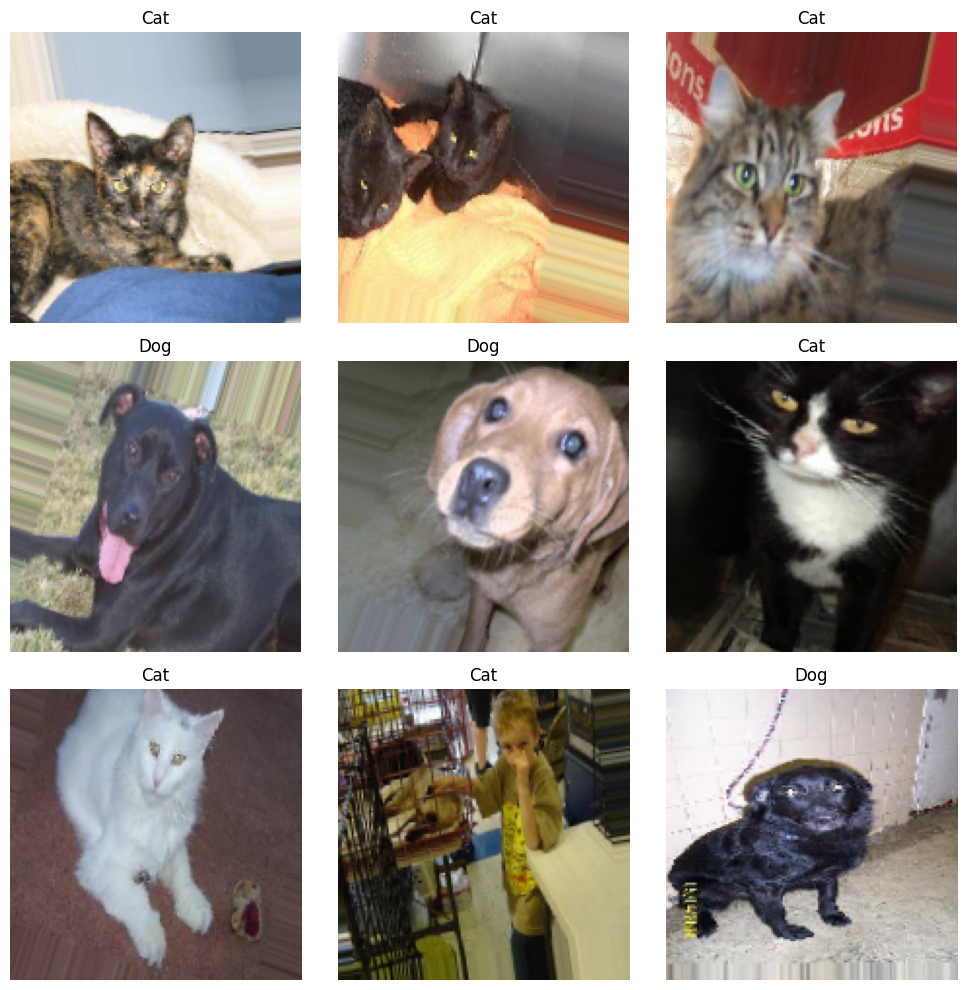

In [11]:
# ---------------------------------------------
# VISUALIZE DATA AUGMENTATION
# ---------------------------------------------

# Create a separate generator only for visualization.
# We do NOT use VGG16 preprocessing here because
# we want to see the augmented images normally.

visualization_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Load one batch of images with augmentation
visualization_generator = visualization_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=9,
    class_mode="binary",
    shuffle=True
)

# Get one batch
images, labels = next(visualization_generator)

# Display augmented images
plt.figure(figsize=(10, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    # Display image
    plt.imshow(images[i].astype("uint8"))

    # Convert label to class name
    if labels[i] == 0:
        class_name = "Cat"
    else:
        class_name = "Dog"

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Compile the model

model.compile(
    optimizer="adam",

    # Binary classification loss
    loss="binary_crossentropy",

    # Measure accuracy
    metrics=["accuracy"]
)

In [13]:
# Train the model

history = model.fit(
    train_generator,

    # Number of training epochs
    epochs=10,

    # Validation data
    validation_data=validation_generator
)

Epoch 1/10
  2/625 ━━━━━━━━━━━━━━━━━━━━ 55s 90ms/step - accuracy: 0.4609 - loss: 4.8135  

I0000 00:00:1790847620.925575      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 240s 371ms/step - accuracy: 0.9330 - loss: 0.4310 - val_accuracy: 0.9648 - val_loss: 0.0950
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 160s 256ms/step - accuracy: 0.9538 - loss: 0.1238 - val_accuracy: 0.9682 - val_loss: 0.0871
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 157s 251ms/step - accuracy: 0.9585 - loss: 0.1066 - val_accuracy: 0.9702 - val_loss: 0.0807
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 253ms/step - accuracy: 0.9603 - loss: 0.1058 - val_accuracy: 0.9698 - val_loss: 0.0824
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 158s 252ms/step - accuracy: 0.9620 - loss: 0.0994 - val_accuracy: 0.9710 - val_loss: 0.0789
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 250ms/step - accuracy: 0.9638 - loss: 0.0932 - val_accuracy: 0.9708 - val_loss: 0.0836
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.9650 - loss: 0.0947 - val_accuracy: 0.9616 - val_loss: 0.1053
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 249ms/step - accuracy: 0.9639 - loss: 0.09

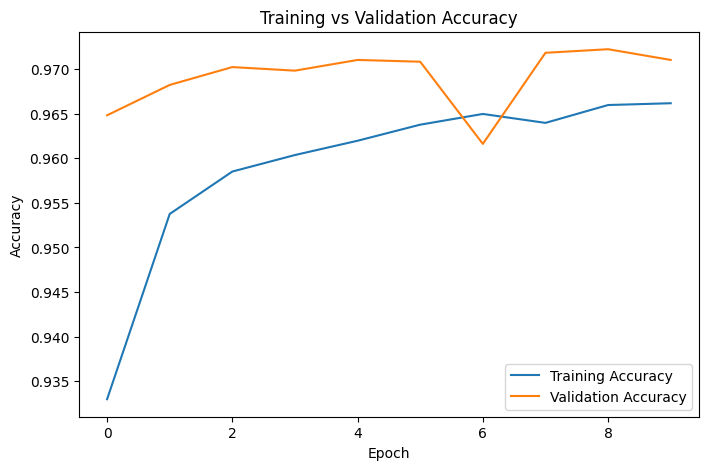

In [14]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

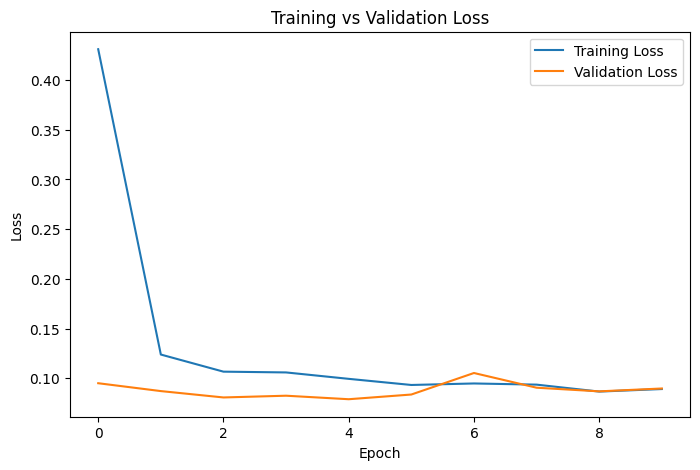

In [15]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [16]:
# Evaluate the trained model on validation/test data

loss, accuracy = model.evaluate(
    validation_generator
)

print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9710 - loss: 0.0897
Test Loss     : 0.08968087285757065
Test Accuracy : 0.9710000157356262


In [17]:
# Function to predict a single image

def predict_image(image_path):

    # Load image
    img = load_img(
        image_path,
        target_size=(150, 150)
    )

    # Convert image into NumPy array
    img_array = img_to_array(img)

    # Add batch dimension
    # (150,150,3) -> (1,150,150,3)
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Apply the same preprocessing used during training
    img_array = preprocess_input(img_array)

    # Make prediction
    prediction = model.predict(
        img_array,
        verbose=0
    )[0][0]

    # Get class mapping
    class_indices = train_generator.class_indices

    # Reverse the dictionary
    index_to_class = {
        value: key
        for key, value in class_indices.items()
    }

    # Convert probability into class
    predicted_index = 1 if prediction >= 0.5 else 0

    predicted_class = index_to_class[predicted_index]

    # Calculate confidence
    if prediction >= 0.5:
        confidence = prediction
    else:
        confidence = 1 - prediction

    return predicted_class, confidence

In [18]:
# Find image files available inside the Kaggle input directory

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
)

image_files = []

for root, dirs, files in os.walk("/kaggle/input"):

    for file in files:

        if file.lower().endswith(image_extensions):

            image_files.append(
                os.path.join(root, file)
            )

print("Number of images found:", len(image_files))

# Display first 10 image paths

for image in image_files[:10]:
    print(image)

Number of images found: 25000
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.375.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.704.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.8597.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5740.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5703.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.7717.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.2618.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.1956.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5608.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5646.jpg


In [19]:
# Select one image as input

input_image = image_files[0]

print("Input image:")
print(input_image)

Input image:
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.375.jpg


In [20]:
# Predict the input image

predicted_class, confidence = predict_image(
    input_image
)

print("INPUT  :", input_image)

print(
    "OUTPUT :",
    predicted_class
)

print(
    "CONFIDENCE :",
    round(confidence * 100, 2),
    "%"
)

INPUT  : /kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.375.jpg
OUTPUT : dogs
CONFIDENCE : 100.0 %


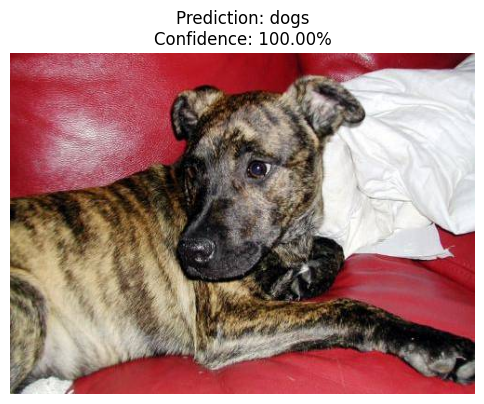

In [21]:
# Display the input image along with the prediction

img = load_img(input_image)

plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.show()